In [1]:
!pip -q install yfinance ipywidgets


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
alpaca-trade-api 3.2.0 requires websockets<11,>=9.0, but you have websockets 16.0 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import display, clear_output

START_DATE = "2018-01-01"

# ✅ Listas de ejemplo (ajústalas a tu gusto)
UNIVERSES = {
    "Tech IA (grandes + semis + cloud)": [
        "NVDA","MSFT","GOOGL","AMZN","META","AAPL",
        "TSLA","AMD","INTC","AVGO","TSM","ASML",
        "ADBE","CRM","ORCL","IBM",
        "PLTR","SNOW","NOW","DDOG",
    ],
    "Semiconductores": ["NVDA","AMD","INTC","AVGO","TSM","ASML","QCOM","MU","AMAT","LRCX","KLAC"],
    "Cloud/SaaS": ["MSFT","AMZN","GOOGL","ORCL","CRM","NOW","SNOW","DDOG","ADBE"],
    "ETFs IA/Tech (para referencia)": ["QQQ","SPY","SOXX","SMH","BOTZ","ARKQ","IRBO","AIQ"],
}

DEFAULT_UNIVERSE = "Tech IA (grandes + semis + cloud)"


In [3]:
def fetch_prices(tickers, start=START_DATE):
    tickers = [t.strip().upper() for t in tickers if t.strip()]
    if not tickers:
        raise ValueError("No hay tickers seleccionados.")
    
    df = yf.download(
        tickers=tickers,
        start=start,
        auto_adjust=True,     # ajustado por splits/dividendos
        progress=False,
        group_by="column",
        threads=True
    )
    # Si es 1 ticker, yfinance regresa columnas planas
    if isinstance(df.columns, pd.MultiIndex):
        close = df["Close"].copy()
    else:
        close = df[["Close"]].copy()
        close.columns = tickers  # renombrar a ticker
    
    close = close.dropna(how="all")
    return close

def normalize_to_100(price_df):
    # Cada serie inicia en 100 en el primer dato disponible
    first_valid = price_df.apply(lambda s: s.dropna().iloc[0] if s.dropna().shape[0] else np.nan)
    norm = price_df.divide(first_valid, axis=1) * 100.0
    return norm

def plot_overlaid(norm_df, title="Precios normalizados (inicio=100)"):
    plt.figure(figsize=(12,6))
    plt.plot(norm_df.index, norm_df.values)
    plt.title(title)
    plt.xlabel("Fecha")
    plt.ylabel("Índice (100 = inicio)")
    plt.grid(True, alpha=0.3)
    plt.legend(norm_df.columns, ncols=3, fontsize=9, loc="upper left")
    plt.show()

def plot_cum_return(price_df, title="Rendimiento acumulado (%)"):
    # rendimiento acumulado relativo al primer dato disponible
    first_valid = price_df.apply(lambda s: s.dropna().iloc[0] if s.dropna().shape[0] else np.nan)
    ret = (price_df.divide(first_valid, axis=1) - 1.0) * 100.0
    plt.figure(figsize=(12,6))
    plt.plot(ret.index, ret.values)
    plt.title(title)
    plt.xlabel("Fecha")
    plt.ylabel("%")
    plt.grid(True, alpha=0.3)
    plt.legend(ret.columns, ncols=3, fontsize=9, loc="upper left")
    plt.show()

def plot_corr_heatmap(price_df, title="Correlación (retornos diarios)"):
    rets = price_df.pct_change().dropna(how="all")
    corr = rets.corr()

    plt.figure(figsize=(8,6))
    plt.imshow(corr.values)
    plt.title(title)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.index)), corr.index)
    plt.colorbar()
    plt.tight_layout()
    plt.show()


In [4]:
universe_dd = widgets.Dropdown(
    options=list(UNIVERSES.keys()),
    value=DEFAULT_UNIVERSE,
    description="Universo:",
    layout=widgets.Layout(width="520px")
)

manual_tickers = widgets.Text(
    value="",
    description="Manual:",
    placeholder="Ej: NVDA, MSFT, GOOGL",
    layout=widgets.Layout(width="520px")
)

tickers_ms = widgets.SelectMultiple(
    options=UNIVERSES[DEFAULT_UNIVERSE],
    value=tuple(UNIVERSES[DEFAULT_UNIVERSE][:6]),
    description="Tickers:",
    layout=widgets.Layout(width="520px", height="180px")
)

start_text = widgets.Text(
    value=START_DATE,
    description="Desde:",
    layout=widgets.Layout(width="260px")
)

mode_rb = widgets.RadioButtons(
    options=[
        ("Normalizado (inicio=100)", "norm"),
        ("Rendimiento acumulado (%)", "ret"),
        ("Ambos", "both"),
    ],
    value="norm",
    description="Modo:"
)

corr_cb = widgets.Checkbox(value=False, description="Mostrar correlación (heatmap)")

run_btn = widgets.Button(description="Descargar + Graficar", button_style="success")
out = widgets.Output()

def on_universe_change(change):
    uni = change["new"]
    tickers_ms.options = UNIVERSES[uni]
    # set default selection: primeros 6
    tickers_ms.value = tuple(list(UNIVERSES[uni])[:6])

universe_dd.observe(on_universe_change, names="value")

def on_run_clicked(_):
    with out:
        clear_output()
        # tickers: multiselect + manual (si existe)
        selected = list(tickers_ms.value)
        extra = [t.strip().upper() for t in manual_tickers.value.split(",") if t.strip()]
        tickers = list(dict.fromkeys(selected + extra))  # únicos conservando orden

        print("Tickers:", tickers)
        print("Descargando desde:", start_text.value)

        try:
            prices = fetch_prices(tickers, start=start_text.value)
        except Exception as e:
            print("Error descargando:", e)
            return

        # Limpieza ligera
        prices = prices.dropna(how="all")
        if prices.empty:
            print("No se obtuvieron datos. Revisa tickers o fecha.")
            return

        if mode_rb.value in ("norm", "both"):
            norm = normalize_to_100(prices)
            plot_overlaid(norm, title=f"Normalizado (inicio=100) — desde {start_text.value}")

        if mode_rb.value in ("ret", "both"):
            plot_cum_return(prices, title=f"Rendimiento acumulado (%) — desde {start_text.value}")

        if corr_cb.value and prices.shape[1] >= 2:
            plot_corr_heatmap(prices)

run_btn.on_click(on_run_clicked)

controls = widgets.VBox([
    universe_dd,
    tickers_ms,
    manual_tickers,
    widgets.HBox([start_text]),
    mode_rb,
    corr_cb,
    run_btn
])

display(controls, out)


Output()

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

START_DATE = "2018-01-01"

UNIVERSES = {
    "IA (infra + cloud + data)": [
        "NVDA","MSFT","GOOGL","AMZN","META",
        "AMD","AVGO","TSM","ASML",
        "PLTR","SNOW","NOW","DDOG","CRM","ADBE"
    ],
    "Activos duros (ETFs fáciles)": [
        "GLD",   # Oro
        "SLV",   # Plata
        "USO",   # Petróleo WTI (ETF)
        "UNG",   # Gas natural (ETF)
        "CPER",  # Cobre (ETF)
        "DBA",   # Agricultura (commodities agrícolas)
        "WOOD",  # Madera/forestal (proxy)
    ],
    "Futuros (a veces fallan)": [
        "GC=F",  # Oro
        "SI=F",  # Plata
        "CL=F",  # Crudo WTI
        "NG=F",  # Gas natural
        "HG=F",  # Cobre
    ],
    "Benchmarks (opcional)": ["SPY","QQQ","TLT","DXY"]  # DXY a veces no está; depende
}


In [6]:
def fetch_prices(tickers, start=START_DATE):
    tickers = [t.strip().upper() for t in tickers if t.strip()]
    df = yf.download(
        tickers=tickers,
        start=start,
        auto_adjust=True,
        progress=False,
        threads=True,
        group_by="column",
    )
    if isinstance(df.columns, pd.MultiIndex):
        close = df["Close"].copy()
    else:
        close = df[["Close"]].copy()
        close.columns = tickers
    close = close.dropna(how="all")
    return close

def normalize_to_100(price_df):
    first_valid = price_df.apply(lambda s: s.dropna().iloc[0] if len(s.dropna()) else np.nan)
    return price_df.divide(first_valid, axis=1) * 100.0

def aligned_daily(price_df):
    # re-muestreo diario y forward-fill para alinear activos con calendarios distintos
    daily = price_df.resample("1D").last().ffill()
    return daily

def returns_df(price_df):
    return price_df.pct_change().dropna(how="all")


In [ ]:
# --- Estado global (para que se quede lo graficado)
LAYERS = []   # cada layer = dict(name, tickers, norm_df)

# Controles
universe_dd = widgets.Dropdown(options=list(UNIVERSES.keys()), value="IA (infra + cloud + data)", description="Grupo:")
tickers_ms = widgets.SelectMultiple(options=UNIVERSES[universe_dd.value], value=tuple(UNIVERSES[universe_dd.value][:6]), description="Tickers:", layout=widgets.Layout(width="520px", height="180px"))
manual = widgets.Text(value="", description="Manual:", placeholder="Ej: GLD, SLV, USO", layout=widgets.Layout(width="520px"))
layer_name = widgets.Text(value="Capa 1", description="Nombre:", layout=widgets.Layout(width="520px"))
start_text = widgets.Text(value=START_DATE, description="Desde:", layout=widgets.Layout(width="260px"))

mode_rb = widgets.RadioButtons(
    options=[("Normalizado (100)", "norm"), ("Rend. acumulado (%)", "ret")],
    value="norm",
    description="Vista:"
)

btn_add = widgets.Button(description="Agregar capa", button_style="success")
btn_reset = widgets.Button(description="Reset gráfico", button_style="warning")
btn_stats = widgets.Button(description="Stats (correlación/beta)", button_style="info")

out = widgets.Output()

def on_universe_change(change):
    tickers_ms.options = UNIVERSES[change["new"]]
    tickers_ms.value = tuple(list(UNIVERSES[change["new"]])[:6])

universe_dd.observe(on_universe_change, names="value")

def plot_layers():
    if not LAYERS:
        print("No hay capas aún.")
        return
    
    plt.figure(figsize=(12,6))
    for layer in LAYERS:
        df = layer["df"]
        # Plotear todas las columnas de esa capa
        plt.plot(df.index, df.values, label=None)
    plt.title("Capas superpuestas (se mantienen en pantalla)")
    plt.xlabel("Fecha")
    plt.grid(True, alpha=0.3)

    # Leyenda compacta: mostramos tickers por capa (texto)
    legend_lines = []
    for layer in LAYERS:
        legend_lines.append(f'{layer["name"]}: {", ".join(layer["tickers"])}')
    plt.legend(legend_lines, fontsize=8, loc="upper left")
    plt.show()

def add_layer(_):
    with out:
        # NO limpiar output => se queda el historial en el notebook
        selected = list(tickers_ms.value)
        extra = [t.strip().upper() for t in manual.value.split(",") if t.strip()]
        tickers = list(dict.fromkeys(selected + extra))
        if not tickers:
            print("Selecciona al menos 1 ticker.")
            return

        try:
            prices = fetch_prices(tickers, start=start_text.value)
        except Exception as e:
            print("Error descargando:", e)
            return

        prices = aligned_daily(prices).dropna(how="all")
        if prices.empty:
            print("Sin datos. Revisa tickers/fecha.")
            return

        if mode_rb.value == "norm":
            df_plot = normalize_to_100(prices)
        else:
            first_valid = prices.apply(lambda s: s.dropna().iloc[0] if len(s.dropna()) else np.nan)
            df_plot = (prices.divide(first_valid, axis=1) - 1.0) * 100.0

        layer = {"name": layer_name.value.strip() or f"Capa {len(LAYERS)+1}",
                 "tickers": tickers,
                 "df": df_plot}
        LAYERS.append(layer)

        print(f"✅ Agregada capa: {layer['name']}")
        plot_layers()

def reset(_):
    with out:
        LAYERS.clear()
        print("🧹 Reset listo. Ya no hay capas.")

def stats(_):
    with out:
        if len(LAYERS) < 2:
            print("Agrega al menos 2 capas (por ejemplo IA y Activos duros) para comparar.")
            return
        
        # Combinar todos los tickers descargados en capas
        all_tickers = []
        for layer in LAYERS:
            all_tickers += layer["tickers"]
        all_tickers = list(dict.fromkeys(all_tickers))

        prices = fetch_prices(all_tickers, start=start_text.value)
        prices = aligned_daily(prices).dropna(how="all")
        rets = returns_df(prices)

        # Correlación
        corr = rets.corr()

        print("📌 Correlación (retornos diarios) — muestra parcial:")
        display(corr)

        # Beta de cada ticker vs SPY si está
        if "SPY" in rets.columns:
            spy = rets["SPY"].dropna()
            betas = {}
            for c in rets.columns:
                if c == "SPY": 
                    continue
                x = spy.align(rets[c], join="inner")[0]
                y = spy.align(rets[c], join="inner")[1]
                if len(x) > 50:
                    beta = np.cov(y, x)[0,1] / np.var(x)
                    betas[c] = beta
            if betas:
                beta_s = pd.Series(betas).sort_values(ascending=False)
                print("\n📌 Beta vs SPY (aprox):")
                display(beta_s)
        else:
            print("\nTip: agrega SPY como benchmark si quieres beta (Universo: Benchmarks).")

btn_add.on_click(add_layer)
btn_reset.on_click(reset)
btn_stats.on_click(stats)

controls = widgets.VBox([
    universe_dd,
    tickers_ms,
    manual,
    layer_name,
    widgets.HBox([start_text, mode_rb]),
    widgets.HBox([btn_add, btn_stats, btn_reset])
])

display(controls, out)


Output()


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


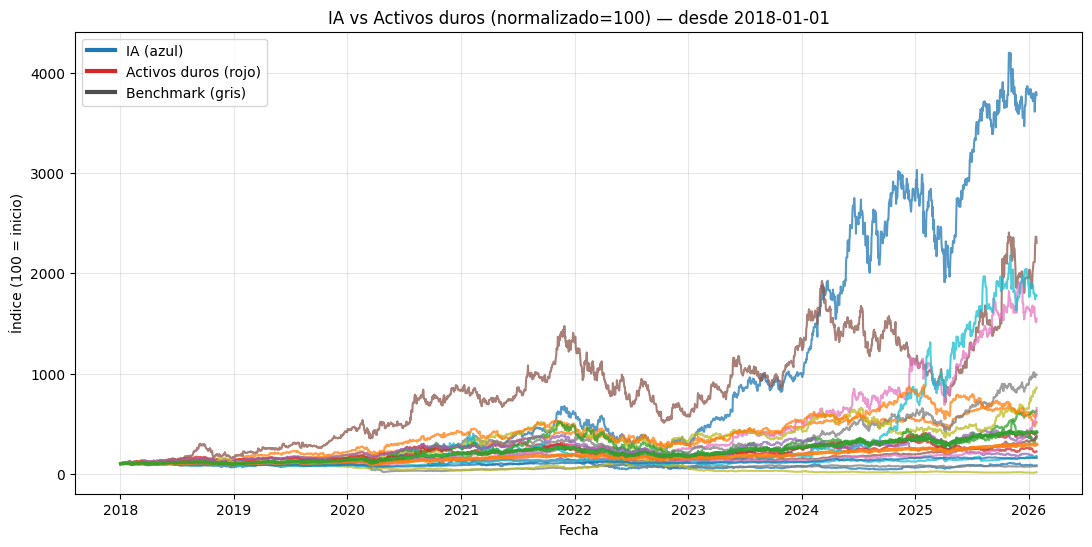

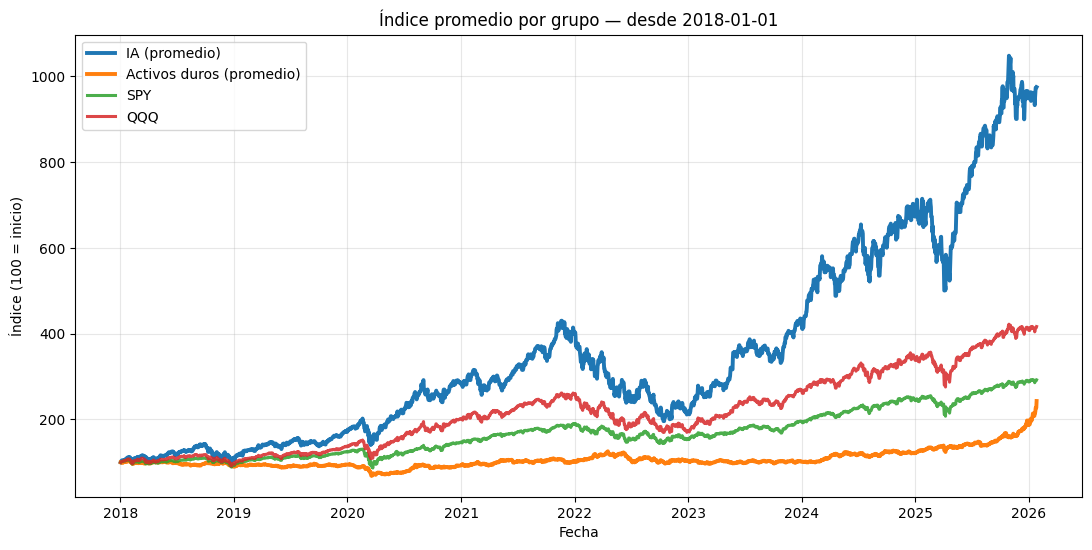

,TotalReturn_%,AnnVol_%
Ticker,,
NVDA,3681.04,42.61
AMD,2206.01,42.96
AVGO,1449.51,34.53
TSM,888.26,30.82
ASML,759.98,34.30
SLV,556.35,25.62
GOOGL,529.48,25.61
MSFT,499.00,21.33
NOW,416.28,33.25


In [8]:
!pip -q install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Config
# =========================
START_DATE = "2018-01-01"

# ✅ Empresas IA (edita a tu gusto)
AI_TICKERS = [
    "NVDA","MSFT","GOOGL","AMZN","META",
    "AMD","AVGO","TSM","ASML",
    "PLTR","SNOW","NOW","DDOG","CRM","ADBE"
]

# ✅ Activos duros (ETFs como proxies)
HARD_TICKERS = [
    "GLD",   # Oro
    "SLV",   # Plata
    "USO",   # Petróleo (ETF)
    "UNG",   # Gas natural (ETF)
    "CPER",  # Cobre (ETF)
    "DBA"    # Agricultura (ETF)
]

# Opcional: benchmark mercado / tech
BENCH_TICKERS = ["SPY","QQQ"]  # puedes dejar [] si no quieres

# =========================
# Helpers
# =========================
def fetch_close(tickers, start=START_DATE):
    tickers = [t.strip().upper() for t in tickers if t.strip()]
    df = yf.download(
        tickers=tickers,
        start=start,
        auto_adjust=True,
        progress=False,
        threads=True,
        group_by="column"
    )
    if isinstance(df.columns, pd.MultiIndex):
        close = df["Close"].copy()
    else:
        close = df[["Close"]].copy()
        close.columns = tickers
    close = close.dropna(how="all")

    # alinear calendarios: diario + ffill
    close = close.resample("1D").last().ffill()
    return close

def normalize_100(price_df):
    first = price_df.apply(lambda s: s.dropna().iloc[0] if len(s.dropna()) else np.nan)
    return price_df.divide(first, axis=1) * 100.0

def plot_two_groups(norm_df, ai, hard, bench=None, title=""):
    plt.figure(figsize=(13,6))

    # IA = azul
    for t in ai:
        if t in norm_df.columns:
            plt.plot(norm_df.index, norm_df[t], alpha=0.75)

    # Activos duros = rojo
    for t in hard:
        if t in norm_df.columns:
            plt.plot(norm_df.index, norm_df[t], alpha=0.75)

    # Benchmarks = gris (opcional)
    if bench:
        for t in bench:
            if t in norm_df.columns:
                plt.plot(norm_df.index, norm_df[t], linewidth=2.5, alpha=0.9)

    plt.title(title)
    plt.xlabel("Fecha")
    plt.ylabel("Índice (100 = inicio)")
    plt.grid(True, alpha=0.3)

    # Leyenda “por grupo” (2 etiquetas, no 30)
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0],[0], color="C0", lw=3, label="IA (azul)"),
        Line2D([0],[0], color="C3", lw=3, label="Activos duros (rojo)"),
    ]
    if bench:
        handles.append(Line2D([0],[0], color="0.3", lw=3, label="Benchmark (gris)"))
    plt.legend(handles=handles, loc="upper left")
    plt.show()

def group_index(norm_df, tickers):
    cols = [t for t in tickers if t in norm_df.columns]
    if not cols:
        return None
    # índice igual-ponderado (promedio)
    return norm_df[cols].mean(axis=1)

# =========================
# Run
# =========================
all_tickers = list(dict.fromkeys(AI_TICKERS + HARD_TICKERS + BENCH_TICKERS))
prices = fetch_close(all_tickers, start=START_DATE)
norm = normalize_100(prices)

# 1) Todas las curvas superpuestas, pero solo 2 colores (azul vs rojo)
plot_two_groups(
    norm_df=norm,
    ai=AI_TICKERS,
    hard=HARD_TICKERS,
    bench=BENCH_TICKERS,
    title=f"IA vs Activos duros (normalizado=100) — desde {START_DATE}"
)

# 2) Índices por grupo (promedio) para ver “tendencia” sin ruido
ai_idx = group_index(norm, AI_TICKERS)
hard_idx = group_index(norm, HARD_TICKERS)

plt.figure(figsize=(13,6))
if ai_idx is not None:
    plt.plot(ai_idx.index, ai_idx.values, linewidth=2.8)
if hard_idx is not None:
    plt.plot(hard_idx.index, hard_idx.values, linewidth=2.8)
for b in BENCH_TICKERS:
    if b in norm.columns:
        plt.plot(norm.index, norm[b], linewidth=2.2, alpha=0.85)

plt.title(f"Índice promedio por grupo — desde {START_DATE}")
plt.xlabel("Fecha")
plt.ylabel("Índice (100 = inicio)")
plt.grid(True, alpha=0.3)
plt.legend(["IA (promedio)","Activos duros (promedio)"] + [f"{b}" for b in BENCH_TICKERS], loc="upper left")
plt.show()

# 3) Tabla rápida: rendimiento total desde 2018 y volatilidad anualizada
rets = prices.pct_change().dropna()
total_return = (prices.iloc[-1] / prices.iloc[0] - 1.0) * 100
ann_vol = rets.std() * np.sqrt(252) * 100

summary = pd.DataFrame({
    "TotalReturn_%": total_return.round(2),
    "AnnVol_%": ann_vol.round(2)
}).sort_values("TotalReturn_%", ascending=False)

summary


In [9]:
def plot_two_groups(norm_df, ai, hard, bench=None, title=""):
    plt.figure(figsize=(13,6))

    # IA = azul fijo
    for t in ai:
        if t in norm_df.columns:
            plt.plot(
                norm_df.index,
                norm_df[t],
                color="tab:blue",
                alpha=0.35
            )

    # Activos duros = rojo fijo
    for t in hard:
        if t in norm_df.columns:
            plt.plot(
                norm_df.index,
                norm_df[t],
                color="tab:red",
                alpha=0.35
            )

    # Benchmark = gris fijo (línea más gruesa)
    if bench:
        for t in bench:
            if t in norm_df.columns:
                plt.plot(
                    norm_df.index,
                    norm_df[t],
                    color="black",
                    linewidth=2.8,
                    alpha=0.9
                )

    plt.title(title)
    plt.xlabel("Fecha")
    plt.ylabel("Índice (100 = inicio)")
    plt.grid(True, alpha=0.3)

    # Leyenda manual (una sola por grupo)
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0],[0], color="tab:blue", lw=3, label="IA"),
        Line2D([0],[0], color="tab:red", lw=3, label="Activos duros"),
    ]
    if bench:
        handles.append(Line2D([0],[0], color="black", lw=3, label="Benchmark"))

    plt.legend(handles=handles, loc="upper left")
    plt.show()


prices: (2947, 23)
norm: (2947, 23)
columnas ejemplo: ['ADBE', 'AMD', 'AMZN', 'ASML', 'AVGO', 'CPER', 'CRM', 'DBA', 'DDOG', 'GLD']


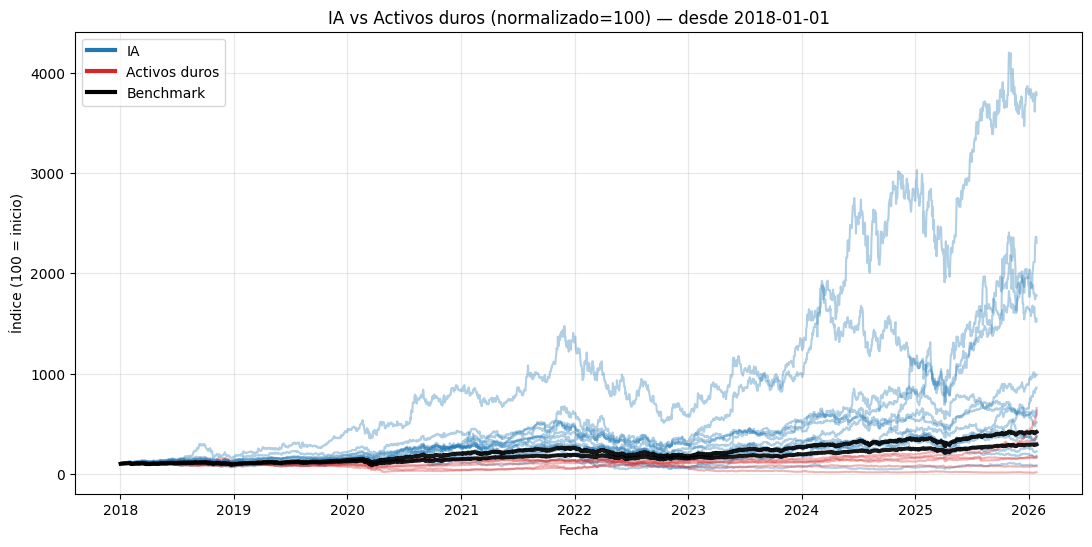

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt

print("prices:", prices.shape)
print("norm:", norm.shape)
print("columnas ejemplo:", list(norm.columns)[:10])

# Llamada REAL a la función (esto es lo que dibuja)
plot_two_groups(
    norm_df=norm,
    ai=AI_TICKERS,
    hard=HARD_TICKERS,
    bench=BENCH_TICKERS,
    title=f"IA vs Activos duros (normalizado=100) — desde {START_DATE}"
)


In [11]:
from datetime import datetime
import pandas as pd

def slice_and_renormalize(prices_df, start=None, months=None):
    df = prices_df.copy()

    if months is not None:
        end = df.index.max()
        start = end - pd.DateOffset(months=months)
        df = df[df.index >= start]
    elif start is not None:
        df = df[df.index >= pd.to_datetime(start)]

    df = df.dropna(how="all")
    norm_local = normalize_100(df)   # normaliza de nuevo dentro del zoom
    return norm_local


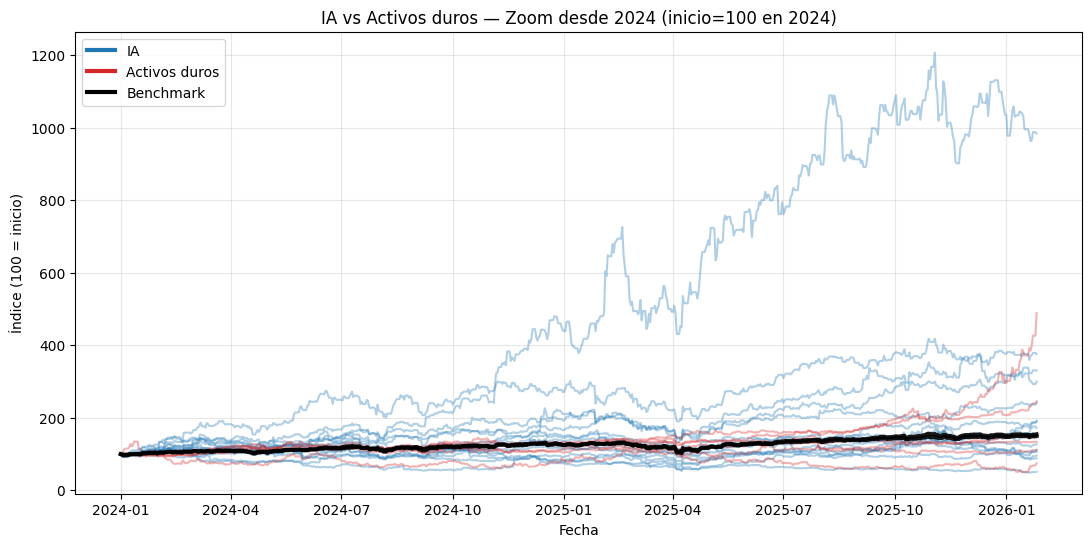

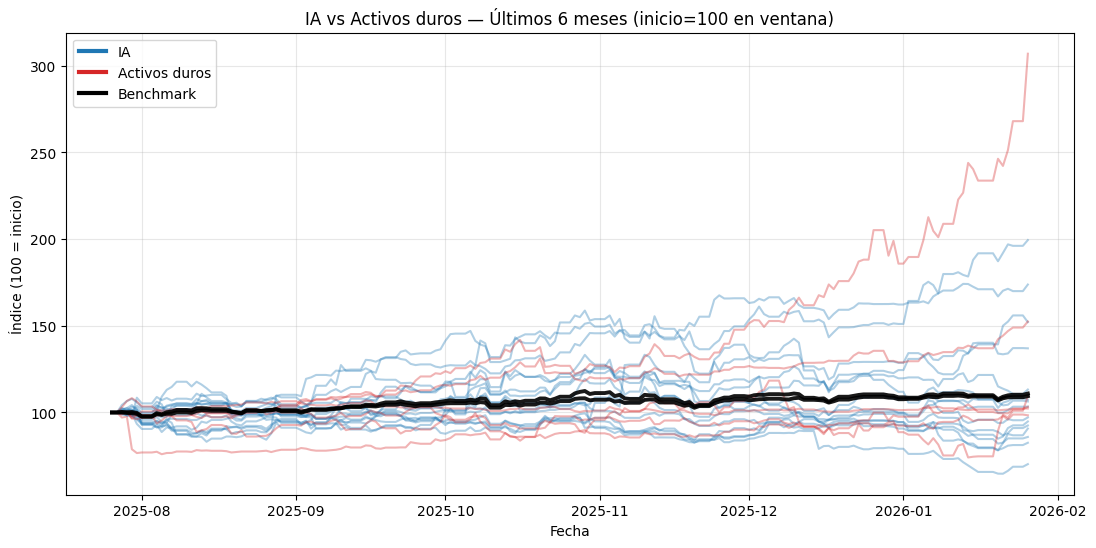

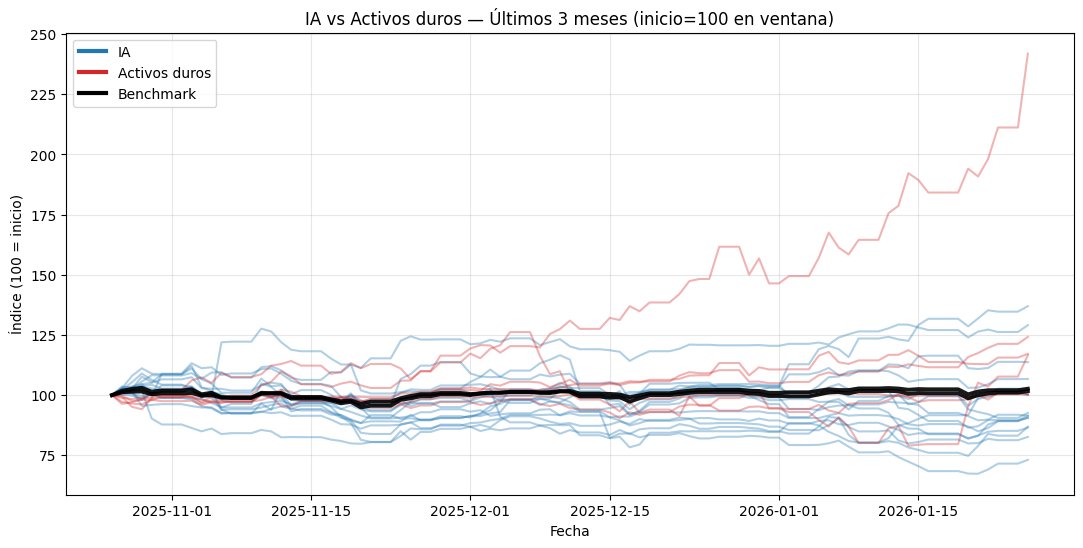

In [12]:
# Zoom desde 2024-01-01
norm_2024 = slice_and_renormalize(prices, start="2024-01-01")
plot_two_groups(
    norm_df=norm_2024,
    ai=AI_TICKERS,
    hard=HARD_TICKERS,
    bench=BENCH_TICKERS,
    title="IA vs Activos duros — Zoom desde 2024 (inicio=100 en 2024)"
)

# Últimos 6 meses
norm_6m = slice_and_renormalize(prices, months=6)
plot_two_groups(
    norm_df=norm_6m,
    ai=AI_TICKERS,
    hard=HARD_TICKERS,
    bench=BENCH_TICKERS,
    title="IA vs Activos duros — Últimos 6 meses (inicio=100 en ventana)"
)

# Últimos 3 meses
norm_3m = slice_and_renormalize(prices, months=3)
plot_two_groups(
    norm_df=norm_3m,
    ai=AI_TICKERS,
    hard=HARD_TICKERS,
    bench=BENCH_TICKERS,
    title="IA vs Activos duros — Últimos 3 meses (inicio=100 en ventana)"
)


confirmacion de la burbuja 

In [13]:
AI_TICKERS = [
    "NVDA","MSFT","GOOGL","AMZN","META",
    "PLTR","SNOW","NOW","DDOG","CRM","ADBE"
]

HARD_TICKERS = [
    "GLD","SLV","USO","UNG","CPER","DBA"
]

SEMI_TICKERS = [
    "NVDA","AMD","INTC","AVGO","TSM","ASML","QCOM","MU","AMAT","LRCX","KLAC"
]

BENCH_TICKERS = ["SPY"]  # opcional, pon [] si no quieres
START_DATE = "2018-01-01"


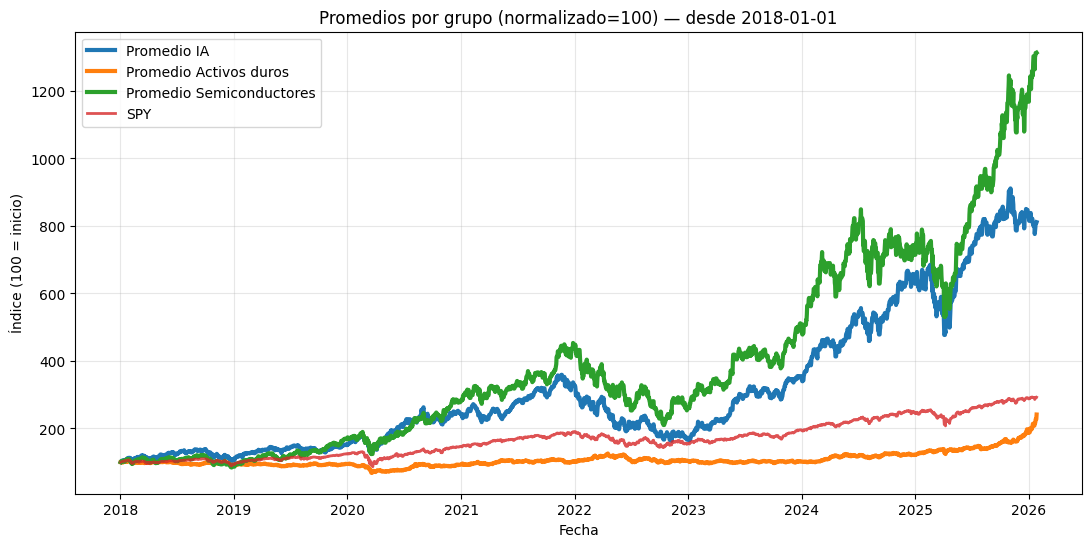

In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def fetch_close(tickers, start):
    tickers = [t.strip().upper() for t in tickers if t.strip()]
    df = yf.download(
        tickers=tickers,
        start=start,
        auto_adjust=True,
        progress=False,
        threads=True,
        group_by="column"
    )
    if isinstance(df.columns, pd.MultiIndex):
        close = df["Close"].copy()
    else:
        close = df[["Close"]].copy()
        close.columns = tickers

    close = close.dropna(how="all").resample("1D").last().ffill()
    return close

def normalize_100(price_df):
    first = price_df.apply(lambda s: s.dropna().iloc[0] if len(s.dropna()) else np.nan)
    return price_df.divide(first, axis=1) * 100.0

def group_mean(norm_df, tickers):
    cols = [t for t in tickers if t in norm_df.columns]
    if not cols:
        return None
    return norm_df[cols].mean(axis=1)

# --- Run
all_tickers = list(dict.fromkeys(AI_TICKERS + HARD_TICKERS + SEMI_TICKERS + BENCH_TICKERS))
prices = fetch_close(all_tickers, START_DATE)
norm = normalize_100(prices)

ai_mean   = group_mean(norm, AI_TICKERS)
hard_mean = group_mean(norm, HARD_TICKERS)
semi_mean = group_mean(norm, SEMI_TICKERS)

plt.figure(figsize=(13,6))

if ai_mean is not None:
    plt.plot(ai_mean.index, ai_mean.values, linewidth=3, label="Promedio IA")
if hard_mean is not None:
    plt.plot(hard_mean.index, hard_mean.values, linewidth=3, label="Promedio Activos duros")
if semi_mean is not None:
    plt.plot(semi_mean.index, semi_mean.values, linewidth=3, label="Promedio Semiconductores")

for b in BENCH_TICKERS:
    if b in norm.columns:
        plt.plot(norm.index, norm[b], linewidth=2, alpha=0.8, label=b)

plt.title(f"Promedios por grupo (normalizado=100) — desde {START_DATE}")
plt.xlabel("Fecha")
plt.ylabel("Índice (100 = inicio)")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.show()


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def slice_prices(prices_df, start=None, months=None):
    df = prices_df.copy()
    if months is not None:
        end = df.index.max()
        start = end - pd.DateOffset(months=months)
        df = df[df.index >= start]
    elif start is not None:
        df = df[df.index >= pd.to_datetime(start)]
    return df.dropna(how="all")

def normalize_100(price_df):
    first = price_df.apply(lambda s: s.dropna().iloc[0] if len(s.dropna()) else np.nan)
    return price_df.divide(first, axis=1) * 100.0

def group_mean(norm_df, tickers):
    cols = [t for t in tickers if t in norm_df.columns]
    if not cols:
        return None
    return norm_df[cols].mean(axis=1)


In [16]:
def plot_group_means(norm_df, ai, hard, semi, title):
    ai_m   = group_mean(norm_df, ai)
    hard_m = group_mean(norm_df, hard)
    semi_m = group_mean(norm_df, semi)

    plt.figure(figsize=(13,6))

    if ai_m is not None:
        plt.plot(ai_m.index, ai_m.values, linewidth=3, label="IA")
    if hard_m is not None:
        plt.plot(hard_m.index, hard_m.values, linewidth=3, label="Activos duros")
    if semi_m is not None:
        plt.plot(semi_m.index, semi_m.values, linewidth=3, label="Semiconductores")

    plt.title(title)
    plt.xlabel("Fecha")
    plt.ylabel("Índice (100 = inicio ventana)")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper left")
    plt.show()


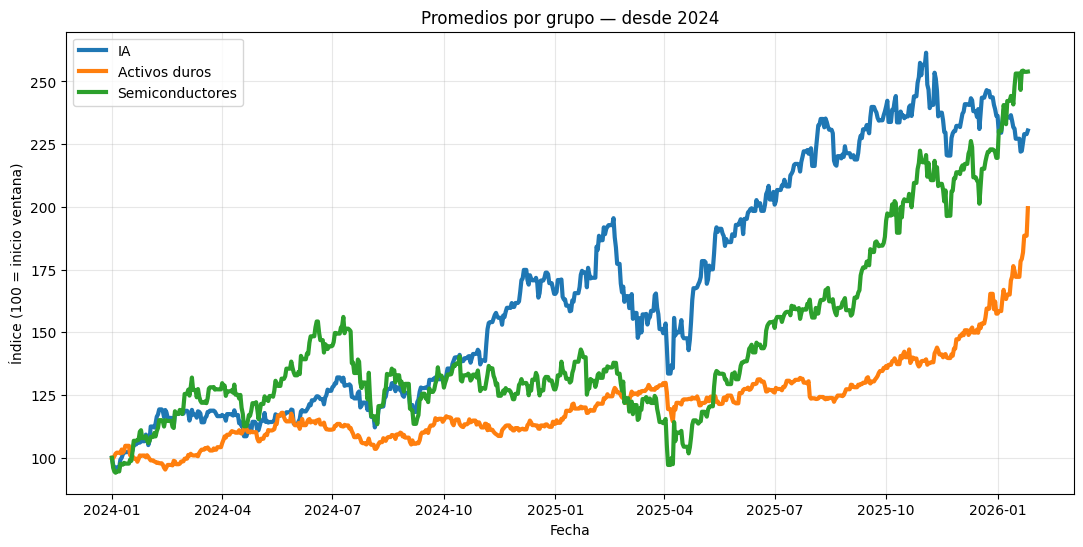

In [17]:
prices_2024 = slice_prices(prices, start="2024-01-01")
norm_2024 = normalize_100(prices_2024)

plot_group_means(
    norm_2024,
    AI_TICKERS,
    HARD_TICKERS,
    SEMI_TICKERS,
    "Promedios por grupo — desde 2024"
)


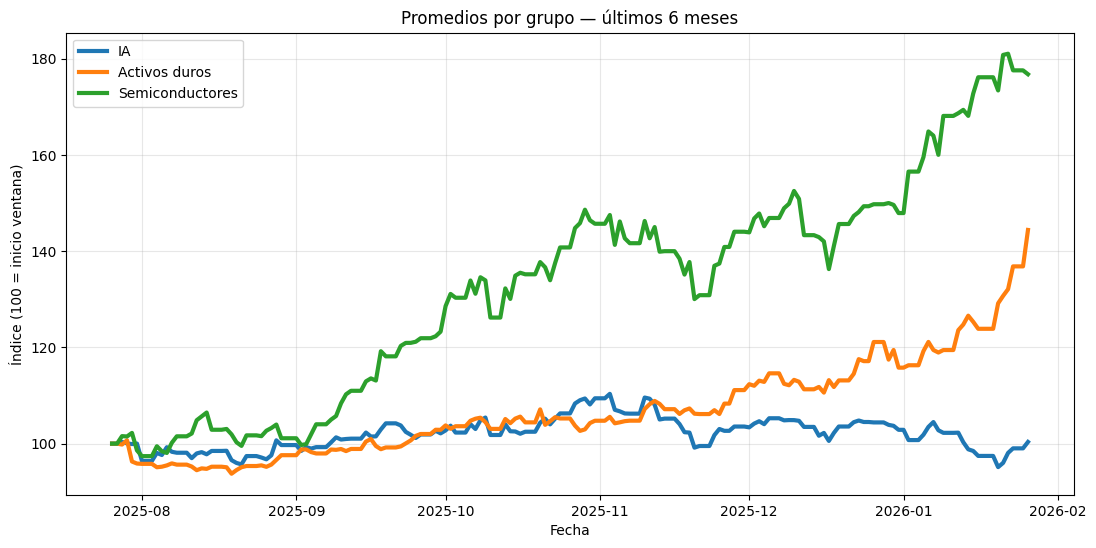

In [18]:
prices_6m = slice_prices(prices, months=6)
norm_6m = normalize_100(prices_6m)

plot_group_means(
    norm_6m,
    AI_TICKERS,
    HARD_TICKERS,
    SEMI_TICKERS,
    "Promedios por grupo — últimos 6 meses"
)


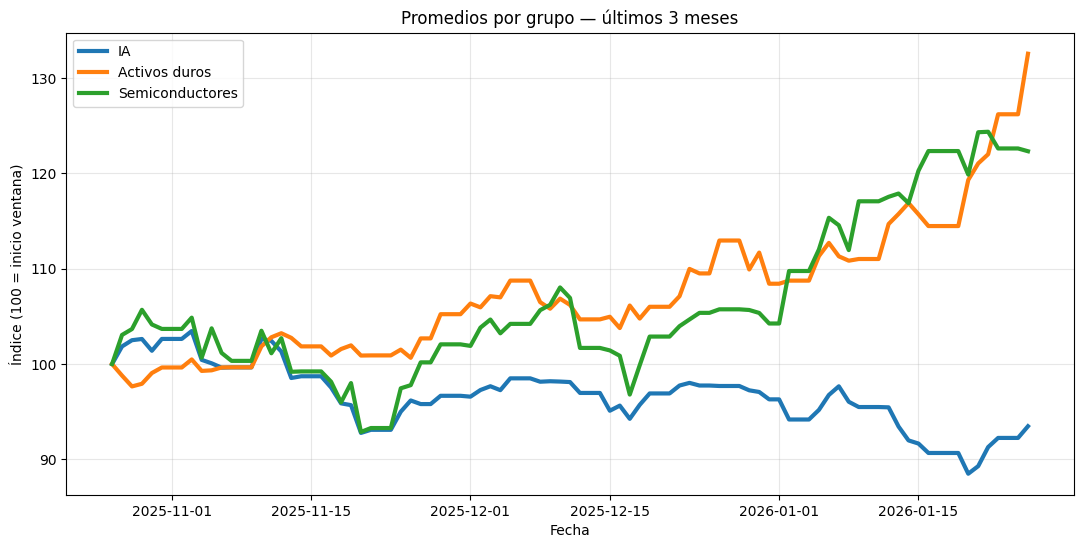

In [19]:
prices_3m = slice_prices(prices, months=3)
norm_3m = normalize_100(prices_3m)

plot_group_means(
    norm_3m,
    AI_TICKERS,
    HARD_TICKERS,
    SEMI_TICKERS,
    "Promedios por grupo — últimos 3 meses"
)
